In [7]:
!pip -q install pygame==2.5.2 imageio imageio-ffmpeg

In [12]:
import numpy as np
from dataclasses import dataclass
import random

REL_ACTIONS = [0, 1, 2]
REL_ACTION_NAMES = {0:"TURN_LEFT", 1:"STRAIGHT", 2:"TURN_RIGHT"}

DIRS = [0, 1, 2, 3]
DIR_VEC = {0:(-1,0), 1:(0,1), 2:(1,0), 3:(0,-1)}
DIR_NAME = {0:"UP",1:"RIGHT",2:"DOWN",3:"LEFT"}

def turn_left(d):  return (d - 1) % 4
def turn_right(d): return (d + 1) % 4

@dataclass
class SnakeConfig:
    grid: int = 12
    max_steps: int = 500
    step_penalty: float = -0.01
    food_reward: float = 1.0
    death_penalty: float = -1.0
    seed: int = 42

class SnakeEnv:
    def __init__(self, cfg: SnakeConfig):
        self.cfg = cfg
        random.seed(cfg.seed)
        np.random.seed(cfg.seed)
        self.grid = cfg.grid

        # ✅ 先建立 state 索引（避免 reset 时 state_id 找不到表）
        self._build_state_index()

        # ✅ 再 reset
        self.reset()

    def _build_state_index(self):
        states = []
        for da in [0,1]:
            for dl in [0,1]:
                for dr in [0,1]:
                    for fx in [-1,0,1]:
                        for fy in [-1,0,1]:
                            for d in [0,1,2,3]:
                                states.append((da,dl,dr,fx,fy,d))
        self.state_to_id = {s:i for i,s in enumerate(states)}
        self.id_to_state = {i:s for s,i in self.state_to_id.items()}

    @property
    def n_states(self):
        return len(self.state_to_id)

    @property
    def n_actions(self):
        return 3

    def reset(self):
        self.steps = 0
        mid = self.grid // 2
        self.dir = 1  # RIGHT
        self.snake = [(mid, mid-1), (mid, mid), (mid, mid+1)]  # tail -> head
        self._place_food()
        self.done = False
        return self.state_id()

    def _place_food(self):
        empty = {(r,c) for r in range(self.grid) for c in range(self.grid)} - set(self.snake)
        self.food = random.choice(list(empty))

    def _is_collision(self, cell):
        r,c = cell
        if r < 0 or r >= self.grid or c < 0 or c >= self.grid:
            return True
        if cell in self.snake:
            return True
        return False

    def _next_dir_from_rel_action(self, rel_action):
        if rel_action == 0:
            return turn_left(self.dir)
        elif rel_action == 2:
            return turn_right(self.dir)
        return self.dir

    def _danger_flags(self):
        head = self.snake[-1]
        d = self.dir

        # ahead
        ar, ac = head[0] + DIR_VEC[d][0], head[1] + DIR_VEC[d][1]
        danger_ahead = 1 if self._is_collision((ar,ac)) else 0

        # left
        ld = turn_left(d)
        lr, lc = head[0] + DIR_VEC[ld][0], head[1] + DIR_VEC[ld][1]
        danger_left = 1 if self._is_collision((lr,lc)) else 0

        # right
        rd = turn_right(d)
        rr, rc = head[0] + DIR_VEC[rd][0], head[1] + DIR_VEC[rd][1]
        danger_right = 1 if self._is_collision((rr,rc)) else 0

        return danger_ahead, danger_left, danger_right

    def _food_direction(self):
        head = self.snake[-1]
        fr, fc = self.food
        hr, hc = head
        fx = -1 if fc < hc else (1 if fc > hc else 0)
        fy = -1 if fr < hr else (1 if fr > hr else 0)
        return fx, fy

    def get_state_tuple(self):
        da, dl, dr = self._danger_flags()
        fx, fy = self._food_direction()
        return (da, dl, dr, fx, fy, self.dir)

    def state_id(self):
        return self.state_to_id[self.get_state_tuple()]

    def step(self, rel_action):
        if self.done:
            return self.state_id(), 0.0, True, {}

        self.steps += 1
        self.dir = self._next_dir_from_rel_action(rel_action)

        head = self.snake[-1]
        nr = head[0] + DIR_VEC[self.dir][0]
        nc = head[1] + DIR_VEC[self.dir][1]
        new_head = (nr, nc)

        if self._is_collision(new_head):
            self.done = True
            return self.state_id(), self.cfg.death_penalty, True, {"event":"death"}

        self.snake.append(new_head)
        reward = self.cfg.step_penalty
        ate = (new_head == self.food)

        if ate:
            reward += self.cfg.food_reward
            self._place_food()
        else:
            self.snake.pop(0)

        if self.steps >= self.cfg.max_steps:
            self.done = True

        return self.state_id(), reward, self.done, {"ate": ate}

In [13]:
def epsilon_greedy(q, s, eps):
    if np.random.rand() < eps:
        return np.random.choice(REL_ACTIONS)
    return int(np.argmax(q[s]))

def train_q_learning(env, episodes=4000, alpha=0.2, gamma=0.9,
                     epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.997):
    q = np.zeros((env.n_states, env.n_actions), dtype=np.float32)

    ep_reward = []
    ep_len = []
    ep_score = []  # 吃到的食物数

    for ep in range(episodes):
        s = env.reset()
        total = 0.0
        score = 0
        done = False

        while not done:
            a = epsilon_greedy(q, s, epsilon)
            s2, r, done, info = env.step(a)

            # Q-learning update
            q[s, a] = q[s, a] + alpha * (r + gamma * np.max(q[s2]) - q[s, a])

            if info.get("ate", False):
                score += 1

            s = s2
            total += r

        ep_reward.append(total)
        ep_len.append(env.steps)
        ep_score.append(score)

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return q, np.array(ep_reward), np.array(ep_len), np.array(ep_score)

cfg = SnakeConfig(grid=12, max_steps=500, seed=42)
env = SnakeEnv(cfg)

q_table, rewards, lengths, scores = train_q_learning(
    env, episodes=4000, alpha=0.2, gamma=0.9, epsilon_decay=0.997
)

print("Training done.",
      "Best score:", int(scores.max()),
      "| Avg score (last 200):", float(scores[-200:].mean()))

Training done. Best score: 36 | Avg score (last 200): 9.075


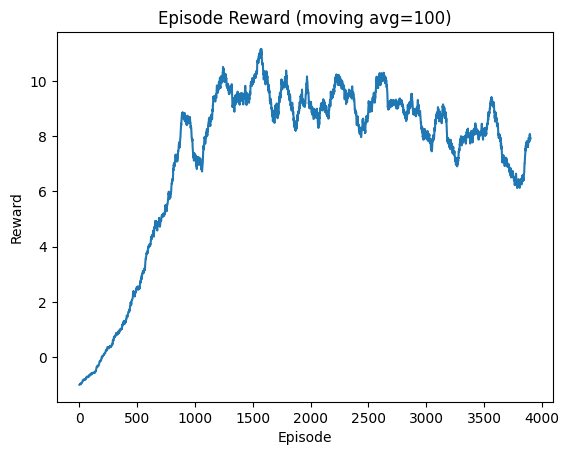

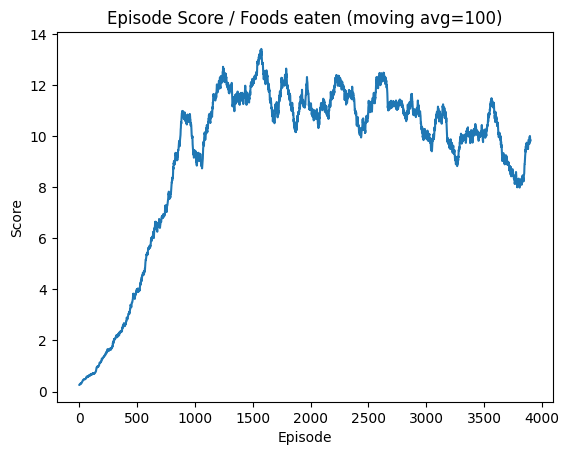

In [14]:
import matplotlib.pyplot as plt

def moving_avg(x, w=100):
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w)/w, mode="valid")

plt.figure()
plt.plot(moving_avg(rewards, 100))
plt.title("Episode Reward (moving avg=100)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

plt.figure()
plt.plot(moving_avg(scores, 100))
plt.title("Episode Score / Foods eaten (moving avg=100)")
plt.xlabel("Episode")
plt.ylabel("Score")
plt.show()

In [15]:
import pygame
import numpy as np

pygame.init()
CELL = 28
PADDING = 10
INFO_H = 60
FONT = pygame.font.SysFont("arial", 18)

def render_frame(env: SnakeEnv, action=None, reward=None):
    g = env.grid
    w = g * CELL + 2*PADDING
    h = g * CELL + 2*PADDING + INFO_H
    surf = pygame.Surface((w, h))
    surf.fill((245,245,245))

    # grid
    for r in range(g):
        for c in range(g):
            x = PADDING + c*CELL
            y = PADDING + r*CELL
            rect = pygame.Rect(x, y, CELL, CELL)
            pygame.draw.rect(surf, (255,255,255), rect)
            pygame.draw.rect(surf, (220,220,220), rect, 1)

    # food
    fr, fc = env.food
    fx = PADDING + fc*CELL
    fy = PADDING + fr*CELL
    pygame.draw.rect(surf, (255,180,180), pygame.Rect(fx+4, fy+4, CELL-8, CELL-8))

    # snake
    for i, (r,c) in enumerate(env.snake):
        x = PADDING + c*CELL
        y = PADDING + r*CELL
        color = (90,150,255) if i == len(env.snake)-1 else (120,190,255)
        pygame.draw.rect(surf, color, pygame.Rect(x+3, y+3, CELL-6, CELL-6))

    # info text
    msg = f"Steps: {env.steps} | Dir: {DIR_NAME[env.dir]}"
    if action is not None:
        msg += f" | Action: {REL_ACTION_NAMES[action]}"
    if reward is not None:
        msg += f" | Reward: {reward:.2f}"
    txt = FONT.render(msg, True, (0,0,0))
    surf.blit(txt, (PADDING, PADDING + g*CELL + 15))

    # to numpy
    frame = pygame.surfarray.array3d(surf)   # (w,h,3)
    frame = np.transpose(frame, (1,0,2))     # (h,w,3)
    return frame

def run_greedy(env, q_table, max_steps=300):
    s = env.reset()
    frames = [render_frame(env)]
    total = 0.0
    done = False

    while not done and env.steps < max_steps:
        a = int(np.argmax(q_table[s]))
        s2, r, done, info = env.step(a)
        frames.append(render_frame(env, action=a, reward=r))
        total += r
        s = s2
    return frames, total, done

frames, total_reward, done = run_greedy(env, q_table, max_steps=300)
print("Greedy demo:", "done=", done, "| steps=", env.steps, "| foods=", len(env.snake)-3, "| total_reward=", round(total_reward, 3))
print("Frames:", len(frames))

Greedy demo: done= True | steps= 187 | foods= 19 | total_reward= 16.14
Frames: 188


In [16]:
import imageio.v2 as imageio
import numpy as np
from pathlib import Path

gif_path = Path("snake_demo.gif")
duration = 0.08  # 越小越快，建议 0.06~0.12

gif_frames = []
for f in frames:
    if f.dtype != np.uint8:
        f = np.clip(f, 0, 255).astype(np.uint8)
    gif_frames.append(f)

# 如果太大：抽帧减小体积
# gif_frames = gif_frames[::2]

imageio.mimsave(gif_path, gif_frames, duration=duration)
print("Saved:", gif_path.resolve())

# 可选：MP4（更适合上传视频）
mp4_path = Path("snake_demo.mp4")
fps = int(round(1/duration))
writer = imageio.get_writer(mp4_path, fps=fps)
for f in gif_frames:
    writer.append_data(f)
writer.close()
print("Saved:", mp4_path.resolve())

Saved: /content/snake_demo.gif


Saved: /content/snake_demo.mp4


In [17]:
import pandas as pd
import zipfile

# Q-table
q_df = pd.DataFrame(q_table, columns=[f"Q_{REL_ACTION_NAMES[a]}" for a in REL_ACTIONS])
q_df.to_csv("q_table.csv", index=False)

# training log
log_df = pd.DataFrame({
    "episode": np.arange(len(rewards)),
    "reward": rewards,
    "steps": lengths,
    "score_foods": scores
})
log_df.to_csv("train_log.csv", index=False)

# zip
out_zip = "Assignment1_Lin_Snake_outputs.zip"
files_to_pack = ["snake_demo.gif", "snake_demo.mp4", "q_table.csv", "train_log.csv"]

with zipfile.ZipFile(out_zip, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for fn in files_to_pack:
        p = Path(fn)
        if p.exists():
            z.write(p, arcname=p.name)
        else:
            print("Missing:", fn)

print("Packed:", out_zip)

Packed: Assignment1_Lin_Snake_outputs.zip


In [18]:
from google.colab import files
files.download("Assignment1_Lin_Snake_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>